# Examples for `stattest` functions

Examples on how to use `statresp.stattest` on synthetic dF/F data where we know the ground truth.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import xarray as xr
from scipy.signal import fftconvolve, lfilter

from statresp import stattest


WINDOW = (0.0, 2.0)

## Synthetic data

`generate_traces` simulates continuous GCaMP6s-like dF/F for a population of cells, as a
`(cell, time)` DataArray, plus alternating `"stim"` / `"shutter"` event times. On `"stim"`
events each cell gets an evoked transient of size `effect`; `effect=0` gives a cell with no
real difference between groups. `drift_sd > 0` adds a slow drift.

`epoch` cuts it into `(cell, trial, time)` around each event with a `stim_type` trial
coordinate, so `epochs.isel(cell=i)` is one cell's `(trial, time)` input for `ks_test` and
`perm_test`, and `dff.isel(cell=i)` is a continuous trace for `circperm_test`.

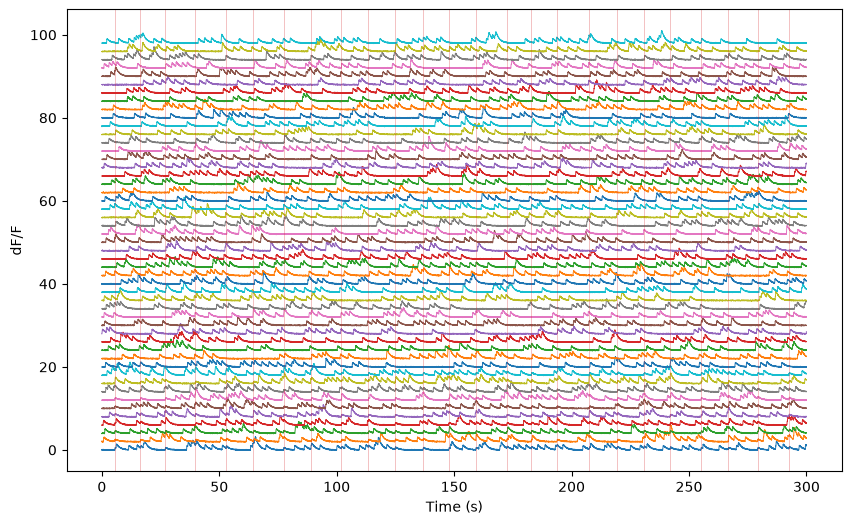

In [2]:
# GCaMP6s kinetics
TAU_RISE = 0.1    # s
TAU_DECAY = 1.5   # s
RATE = 0.2        # mean firing rate (Hz)


def generate_traces(
    n_cells=10,
    duration=300.0,       # s
    fs=45.0,              # imaging frame rate (Hz)
    effect=0.0,           # evoked amplitude on "stim" events, scalar or one per cell
    isi=(5.0, 7.0),       # inter-event interval range (s)
    drift_sd=0.0,         # sd of slow Ornstein-Uhlenbeck drift (0 = none)
    drift_tau=20.0,       # drift time constant (s)
    seed=2026,
):
    """
    Simulate dF/F traces from Poisson spike trains, with alternating stim / shutter events.

    Returns dff, dims (cell, time) with a `spikes` coord, and events, dims (event,) holding
    the event times with a `stim_type` coord.
    """
    rng = np.random.default_rng(seed)
    n_frames = int(round(duration * fs))
    dt = 1 / fs
    t = np.arange(n_frames) / fs

    spikes = rng.poisson(RATE * dt, (n_cells, n_frames))

    # double-exponential kernel, peak = 1
    kt = np.arange(0, 8 * TAU_DECAY, dt)
    kernel = np.exp(-kt / TAU_DECAY) - np.exp(-kt / TAU_RISE)
    kernel /= kernel.max()

    # events every isi s, alternating stim / shutter; only stim events evoke a response
    event_times = np.cumsum(rng.uniform(*isi, size=int(duration / isi[0])))
    event_times = event_times[event_times < duration - 5.0]
    stim_type = np.array(["stim", "shutter"] * len(event_times))[: len(event_times)]
    ev_train = np.zeros(n_frames)
    ev_train[np.searchsorted(t, event_times[stim_type == "stim"])] = 1.0
    drive = spikes + np.asarray(effect, dtype=float).reshape(-1, 1) * ev_train

    ca = fftconvolve(drive, kernel[None], axes=1)[:, :n_frames]
    dff = ca + rng.normal(0, 0.05, ca.shape)  # add noise

    if drift_sd > 0:
        a = np.exp(-dt / drift_tau)
        eps = rng.normal(0.0, drift_sd * np.sqrt(1 - a**2), ca.shape)
        dff += lfilter([1.0], [1.0, -a], eps, axis=1)

    dff = xr.DataArray(
        dff,
        dims=("cell", "time"),
        coords={"cell": np.arange(n_cells), "time": t, "spikes": (("cell", "time"), spikes)},
    )
    events = xr.DataArray(event_times, dims="event", coords={"stim_type": ("event", stim_type)})
    return dff, events


def epoch(dff, events, window=(-1.0, 3.0)):
    """Cut dff (cell, time) into (cell, trial, time) around each event; time is relative to the event."""
    t = dff["time"].values
    dt = float(np.median(np.diff(t)))
    k = np.arange(int(round(window[0] / dt)), int(round(window[1] / dt)))
    ev = np.searchsorted(t, events.values)
    keep = (ev + k[0] >= 0) & (ev + k[-1] < t.size)
    idx = ev[keep][:, None] + k  # (trial, time)
    return xr.DataArray(
        dff.values[:, idx],
        dims=("cell", "trial", "time"),
        coords={
            "cell": dff["cell"].values,
            "trial": np.arange(idx.shape[0]),
            "time": k * dt,
            "stim_type": ("trial", events["stim_type"].values[keep]),
            "event_time": ("trial", events.values[keep]),
        },
    )


# first 10 cells respond to "stim" events, the other 40 don't
dff, events = generate_traces(n_cells=50, effect=np.r_[np.full(10, 0.5), np.zeros(40)])
epochs = epoch(dff, events)
stim_times = events.where(events.stim_type == "stim", drop=True).values

offset = 2
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(dff.sizes["cell"]):
    ax.plot(dff["time"], dff.isel(cell=i) + i * offset, lw=0.7)
for e in stim_times:
    ax.axvline(e, color="C3", lw=0.5, alpha=0.4)
ax.set_xlabel("Time (s)")
ax.set_ylabel("dF/F")
plt.show()

In [3]:
# epochs.isel(cell=i) is one cell's (trial, time); dff.isel(cell=i) goes to circperm_test
for i in [0, 1, 10, 11]:
    cell = epochs.isel(cell=i)
    _, p_ks = stattest.ks_test(cell, "stim_type", window=WINDOW)
    _, p_perm, _ = stattest.perm_test(cell, "stim_type", groups=["stim", "shutter"], window=WINDOW)
    _, p_circ, _ = stattest.circperm_test(dff.isel(cell=i), stim_times, window=(0.0, 2.0), baseline=(-1.0, 0.0))
    print(f"cell {i:>2}: ks p = {p_ks:.2e}, perm p = {p_perm:.4f}, circperm p = {p_circ:.4f}")

# one responsive and one silent cell for the examples below
responsive = epochs.isel(cell=0)
silent = epochs.isel(cell=10)
responsive

cell  0: ks p = 8.31e-03, perm p = 0.0020, circperm p = 0.0010
cell  1: ks p = 1.43e-05, perm p = 0.0010, circperm p = 0.0060


cell 10: ks p = 9.82e-01, perm p = 0.9960, circperm p = 0.2038
cell 11: ks p = 6.29e-01, perm p = 0.8162, circperm p = 0.2787


<xarray.DataArray (trial: 49, time: 180)> Size: 71kB
array([[ 0.00187192,  0.07848869,  0.00279966, ...,  0.3983141 ,
         0.38182599,  0.42602712],
       [ 0.17172986,  0.06778891,  0.15495681, ...,  0.24920895,
         0.25728362,  0.26044497],
       [ 0.93864605,  0.96034941,  0.90980285, ...,  1.05240911,
         1.03686375,  1.01450669],
       ...,
       [ 0.03646071, -0.04639899,  0.02108472, ...,  0.09717467,
         0.0491028 ,  0.10821638],
       [ 0.60760123,  0.51479876,  0.59417682, ...,  0.64674898,
         0.7116795 ,  0.64236822],
       [ 0.53608023,  0.54613628,  0.53244146, ...,  0.04215673,
         0.2260273 ,  0.06823397]], shape=(49, 180))
Coordinates:
  * trial       (trial) int64 392B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48
    stim_type   (trial) <U7 1kB 'stim' 'shutter' 'stim' ... 'shutter' 'stim'
    event_time  (trial) float64 392B 5.476 10.9 16.43 ... 279.2 286.1 292.5
  * time        (time) float64 1kB -1.0 -0.9778 -0.9556 ... 2.933 2.956 2.978
    cell        int64 8B 0

## `ks_test`

The responsive cell should give a large D and a small p; the silent cell should not.

In [4]:
for name, f in [("responsive", responsive), ("silent", silent)]:
    D, p = stattest.ks_test(f, "stim_type", window=WINDOW)
    print(f"{name:>10}: D = {D:.3f}, p = {p:.2e}")

responsive: D = 0.458, p = 8.31e-03
    silent: D = 0.117, p = 9.82e-01


Sanity check: the same numbers straight from `scipy.stats.ks_2samp` on per-trial window means.

In [5]:
def trial_means(f):
    t = f["time"].values
    return f.isel(time=(t >= WINDOW[0]) & (t < WINDOW[1])).mean("time").values


tm = trial_means(responsive)
g = responsive["stim_type"].values
ref = scipy.stats.ks_2samp(tm[g == "shutter"], tm[g == "stim"])
D, p = stattest.ks_test(responsive, "stim_type", window=WINDOW)
print("stattest:", D, p)
print("scipy   :", ref.statistic, ref.pvalue)
assert np.isclose(D, ref.statistic) and np.isclose(p, ref.pvalue)

stattest: 0.4583333333333333 0.008309327533550272
scipy   : 0.4583333333333333 0.008309327533550272


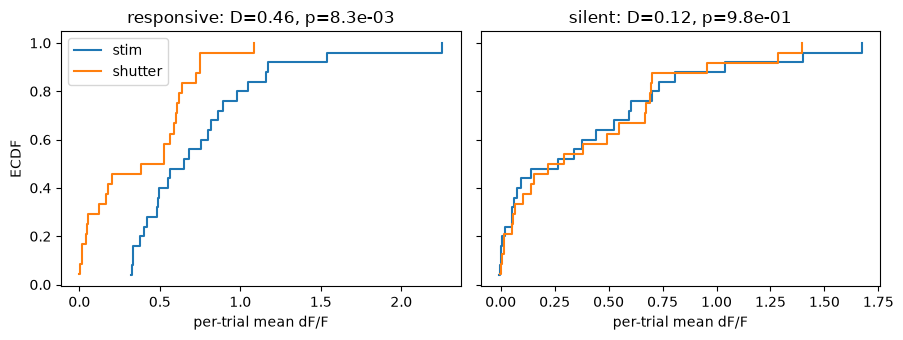

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for ax, (name, f) in zip(axes, [("responsive", responsive), ("silent", silent)]):
    tm = trial_means(f)
    g = f["stim_type"].values
    for level in ["stim", "shutter"]:
        x = np.sort(tm[g == level])
        ax.step(x, np.arange(1, x.size + 1) / x.size, where="post", label=level)
    D, p = stattest.ks_test(f, "stim_type", window=WINDOW)
    ax.set_title(f"{name}: D={D:.2f}, p={p:.1e}")
    ax.set_xlabel("per-trial mean dF/F")
axes[0].set_ylabel("ECDF")
axes[0].legend()
fig.tight_layout()
plt.show()

## `perm_test`

`obs = mean(groups[0]) - mean(groups[1])`. Without `groups`, levels are sorted
alphabetically (`["shutter", "stim"]`), so `obs` is negative for a cell that responds to the
stimulus. Pass `groups=["stim", "shutter"]` to get the sign you expect.

In [7]:
for name, f in [("responsive", responsive), ("silent", silent)]:
    obs, p, null = stattest.perm_test(
        f, "stim_type", groups=["stim", "shutter"], window=WINDOW, n_perm=2000
    )
    print(f"{name:>10}: obs = {obs:+.3f}, p = {p:.4f}")

obs_default, _, _ = stattest.perm_test(responsive, "stim_type", window=WINDOW, n_perm=10)
print("default group order -> obs =", round(obs_default, 3))

responsive: obs = +0.365, p = 0.0020
    silent: obs = -0.001, p = 0.9955
default group order -> obs = -0.365


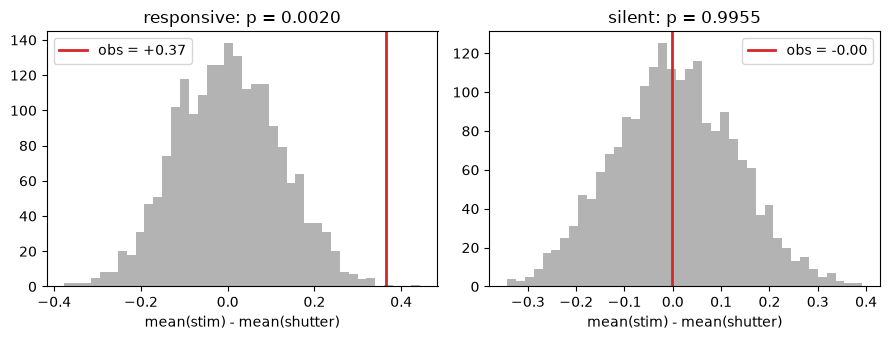

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (name, f) in zip(axes, [("responsive", responsive), ("silent", silent)]):
    obs, p, null = stattest.perm_test(
        f, "stim_type", groups=["stim", "shutter"], window=WINDOW, n_perm=2000
    )
    ax.hist(null, bins=40, color="0.7")
    ax.axvline(obs, color="C3", lw=2, label=f"obs = {obs:+.2f}")
    ax.set_title(f"{name}: p = {p:.4f}")
    ax.set_xlabel("mean(stim) - mean(shutter)")
    ax.legend()
fig.tight_layout()
plt.show()

Reproducibility: the permutation RNG is seeded with `stattest.SEED`, so repeated calls give the same null distribution.

In [9]:
_, p1, null1 = stattest.perm_test(silent, "stim_type", window=WINDOW, n_perm=500)
_, p2, null2 = stattest.perm_test(silent, "stim_type", window=WINDOW, n_perm=500)
assert p1 == p2 and np.array_equal(null1, null2)
print(f"SEED = {stattest.SEED} -> identical null, p =", p1)

SEED = 2026 -> identical null, p = 0.9960079840319361


## Calibration under the null

With no real effect, p-values should be roughly uniform, so about 5% of cells fall below 0.05.

false-positive rate at 0.05: ks = 0.023, perm = 0.040


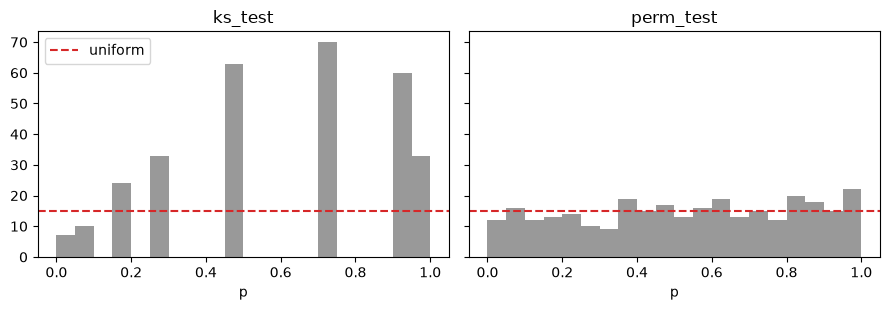

In [10]:
N_NULL = 300
null_dff, null_ev = generate_traces(n_cells=N_NULL, effect=0.0, seed=1)
null_epochs = epoch(null_dff, null_ev)
null_cells = [null_epochs.isel(cell=i) for i in range(N_NULL)]
p_ks = np.array([stattest.ks_test(f, "stim_type", window=WINDOW)[1] for f in null_cells])
p_perm = np.array([
    stattest.perm_test(f, "stim_type", window=WINDOW, n_perm=500)[1]
    for f in null_cells
])

print(f"false-positive rate at 0.05: ks = {np.mean(p_ks < 0.05):.3f}, perm = {np.mean(p_perm < 0.05):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, (name, p) in zip(axes, [("ks_test", p_ks), ("perm_test", p_perm)]):
    ax.hist(p, bins=20, range=(0, 1), color="0.6")
    ax.axhline(N_NULL / 20, color="C3", ls="--", label="uniform")
    ax.set_title(name)
    ax.set_xlabel("p")
axes[0].legend()
fig.tight_layout()
plt.show()

## `fdr` on a population

200 cells, 20% of them responsive. Compare raw p < 0.05 with BH and Storey q < 0.05,
and check BH against `scipy.stats.false_discovery_control`.

In [11]:
N_POP, FRAC_RESP = 200, 0.2
rng = np.random.default_rng(0)
is_resp = rng.random(N_POP) < FRAC_RESP
pop_dff, pop_ev = generate_traces(n_cells=N_POP, effect=np.where(is_resp, 0.6, 0.0), seed=2)
pop_epochs = epoch(pop_dff, pop_ev)
pop = [pop_epochs.isel(cell=i) for i in range(N_POP)]
p_pop = np.array([stattest.ks_test(f, "stim_type", window=WINDOW)[1] for f in pop])

q_bh = stattest.fdr(p_pop, method="bh")
q_storey = stattest.fdr(p_pop, method="storey")
assert np.allclose(q_bh, scipy.stats.false_discovery_control(p_pop, method="bh"))
print("BH matches scipy.stats.false_discovery_control")

rows = []
for name, sig in [("raw p", p_pop < 0.05), ("BH q", q_bh < 0.05), ("Storey q", q_storey < 0.05)]:
    rows.append({
        "criterion": name,
        "n_significant": int(sig.sum()),
        "true_pos": int((sig & is_resp).sum()),
        "false_pos": int((sig & ~is_resp).sum()),
        "observed_FDR": float((sig & ~is_resp).sum() / max(sig.sum(), 1)),
    })
print("true responsive cells:", int(is_resp.sum()))
pd.DataFrame(rows)

BH matches scipy.stats.false_discovery_control
true responsive cells: 37


,criterion,n_significant,true_pos,false_pos,observed_FDR
0,raw p,42,36,6,0.142857
1,BH q,33,33,0,0.000000
2,Storey q,33,33,0,0.000000


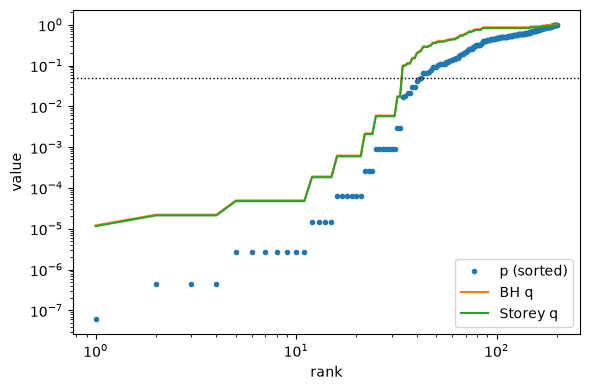

In [12]:
order = np.argsort(p_pop)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, N_POP + 1), p_pop[order], ".", label="p (sorted)")
ax.plot(np.arange(1, N_POP + 1), q_bh[order], "-", label="BH q")
ax.plot(np.arange(1, N_POP + 1), q_storey[order], "-", label="Storey q")
ax.axhline(0.05, color="k", ls=":", lw=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("rank")
ax.set_ylabel("value")
ax.legend()
fig.tight_layout()
plt.show()

## `circperm_test`: event-locked response on a continuous trace

dF/F is autocorrelated: calcium decay keeps neighbouring samples similar, and there can be
slow drift too. A null made by shuffling samples (or trials) treats every sample as
independent, so it's too narrow and gives too many false positives.

`circperm_test` instead circularly shifts the whole trace against the event times. That keeps
the trace's autocorrelation and the spacing between events, and only breaks the alignment
between events and activity.

Here the traces come from `generate_traces(..., drift_sd=0.5)`: spontaneous transients, a slow
drift and noise, plus, for the responsive cell, an evoked transient after each `"stim"` event.
`circperm_test` gets the continuous trace `dff.isel(cell=i)` and the `"stim"` event times.

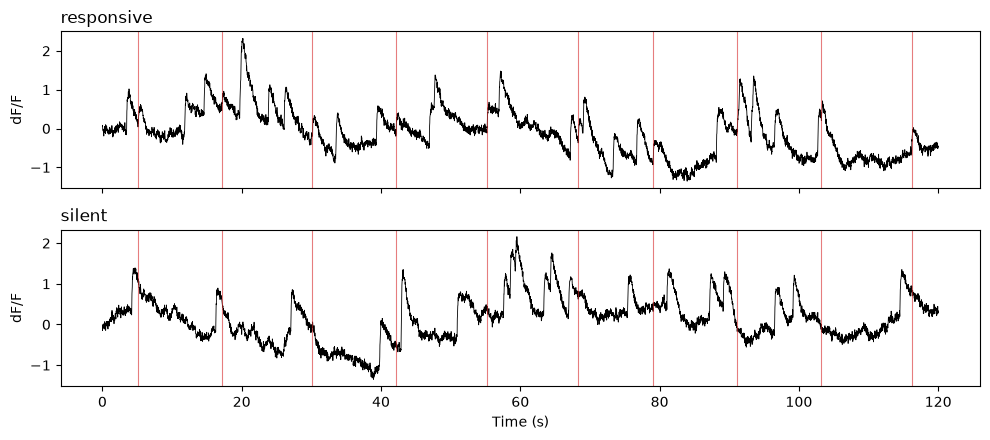

In [13]:
cp_dff, cp_ev = generate_traces(n_cells=2, duration=600.0, effect=[0.5, 0.0], drift_sd=0.5, seed=3)
cp_stim = cp_ev.where(cp_ev.stim_type == "stim", drop=True).values
trace_resp, trace_silent = cp_dff.isel(cell=0), cp_dff.isel(cell=1)
ev_resp = ev_silent = cp_stim

fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
for ax, (name, tr, ev) in zip(axes, [("responsive", trace_resp, ev_resp), ("silent", trace_silent, ev_silent)]):
    seg = tr.sel(time=slice(0, 120))
    ax.plot(seg["time"], seg, lw=0.6, color="k")
    for e in ev[ev < 120]:
        ax.axvline(e, color="C3", lw=0.8, alpha=0.6)
    ax.set_ylabel("dF/F")
    ax.set_title(name, loc="left")
axes[-1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

In [14]:
CP_WINDOW = (0.0, 2.0)
CP_BASELINE = (-1.0, 0.0)

for name, tr, ev in [("responsive", trace_resp, ev_resp), ("silent", trace_silent, ev_silent)]:
    obs, p, _ = stattest.circperm_test(tr, ev, window=CP_WINDOW, n_perm=2000)
    obs_b, p_b, _ = stattest.circperm_test(
        tr, ev, window=CP_WINDOW, baseline=CP_BASELINE, n_perm=2000
    )
    print(f"{name:>10}: no baseline obs = {obs:+.3f}, p = {p:.4f} | "
          f"baseline-subtracted obs = {obs_b:+.3f}, p = {p_b:.4f}")

responsive: no baseline obs = +0.700, p = 0.0005 | baseline-subtracted obs = +0.282, p = 0.0005


    silent: no baseline obs = +0.217, p = 0.2474 | baseline-subtracted obs = -0.099, p = 0.0645


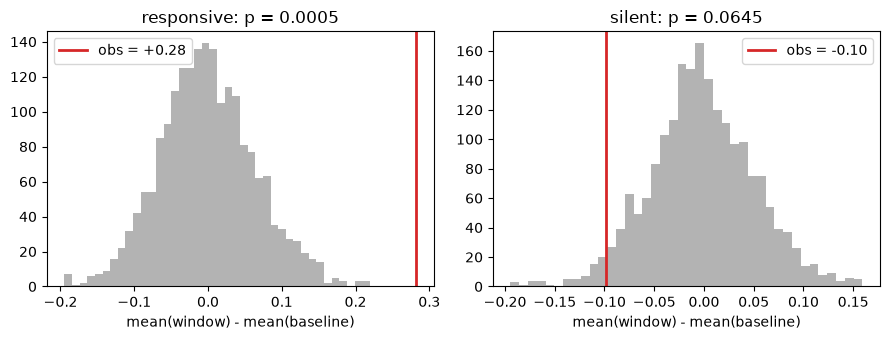

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (name, tr, ev) in zip(axes, [("responsive", trace_resp, ev_resp), ("silent", trace_silent, ev_silent)]):
    obs, p, null = stattest.circperm_test(
        tr, ev, window=CP_WINDOW, baseline=CP_BASELINE, n_perm=2000
    )
    ax.hist(null, bins=40, color="0.7")
    ax.axvline(obs, color="C3", lw=2, label=f"obs = {obs:+.2f}")
    ax.set_title(f"{name}: p = {p:.4f}")
    ax.set_xlabel("mean(window) - mean(baseline)")
    ax.legend()
fig.tight_layout()
plt.show()

### Why circular shifts: calibration on autocorrelated silent cells

Silent cells with slow drift, no baseline subtraction. Compare `circperm_test` against a
naive null that shuffles the samples of the trace (this destroys autocorrelation). Under the
null, about 5% of cells should have p < 0.05.

false-positive rate at 0.05: circperm = 0.040, sample shuffle = 0.725


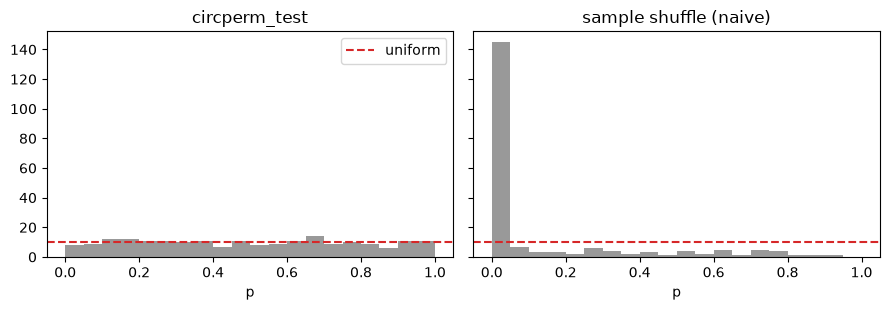

In [16]:
def naive_shuffle_p(trace, event_times, window, n_perm=500, seed=0):
    """Same statistic as circperm_test (no baseline), but the null shuffles samples."""
    rng = np.random.default_rng(seed)
    t = trace["time"].values
    y = trace.values
    dt = np.median(np.diff(t))
    win = np.arange(int(np.ceil(window[0] / dt)), int(np.ceil(window[1] / dt)))
    ev = np.searchsorted(t, event_times)
    ev = ev[(ev + win[0] >= 0) & (ev + win[-1] < y.size)]
    stat = lambda v: v[ev[:, None] + win].mean()
    obs = stat(y)
    null = np.array([stat(rng.permutation(y)) for _ in range(n_perm)])
    mu = null.mean()
    return (1 + np.sum(np.abs(null - mu) >= abs(obs - mu))) / (n_perm + 1)


N_CAL = 200
cal_dff, cal_ev = generate_traces(n_cells=N_CAL, duration=600.0, effect=0.0, drift_sd=0.5, seed=4)
cal_stim = cal_ev.where(cal_ev.stim_type == "stim", drop=True).values
p_circ, p_naive = [], []
for i in range(N_CAL):
    tr = cal_dff.isel(cell=i)
    p_circ.append(stattest.circperm_test(tr, cal_stim, window=CP_WINDOW, n_perm=500)[1])
    p_naive.append(naive_shuffle_p(tr, cal_stim, CP_WINDOW, n_perm=500, seed=i))
p_circ, p_naive = np.array(p_circ), np.array(p_naive)

print(f"false-positive rate at 0.05: circperm = {np.mean(p_circ < 0.05):.3f}, "
      f"sample shuffle = {np.mean(p_naive < 0.05):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, (name, p) in zip(axes, [("circperm_test", p_circ), ("sample shuffle (naive)", p_naive)]):
    ax.hist(p, bins=20, range=(0, 1), color="0.6")
    ax.axhline(N_CAL / 20, color="C3", ls="--", label="uniform")
    ax.set_title(name)
    ax.set_xlabel("p")
axes[0].legend()
fig.tight_layout()
plt.show()

`circperm_test` p-values for a population can go straight into `stattest.fdr`, like the others.

## `zeta_test` and `zeta_two_test`

ZETA (Montijn et al. 2021, eLife) tests for event-locked activity without averaging each trial
into one number, so it needs no response window or baseline and picks up responses of any shape
or latency. Both functions take the continuous trace `dff.isel(cell=i)`, like `circperm_test`,
not the `(trial, time)` epochs.

- `zeta_test(trace, event_times)`: one-sample. Is activity locked to these events, compared with
  jittered event times? There is no control condition, so a cell that responds to the shutter or
  a light artefact also counts as responsive.
- `zeta_two_test(trace, events, "stim_type", groups=["stim", "shutter"])`: two-sample. Does the
  response to stim differ from the response to shutter? Same question as `ks_test` / `perm_test`,
  so this is the one to use for finding visually responsive cells.

Set `max_duration` to the response window (3 s here). The default is the shortest gap between
events, which dilutes a short GCaMP transient. zetapy draws from NumPy's global RNG, which
`stattest` seeds once at import, so rerunning a single cell can give slightly different p-values.

In [17]:
ZETA_DUR = 3.0  # s, response window

for name, i in [("responsive", 0), ("silent", 10)]:
    tr = dff.isel(cell=i)
    z1, p1 = stattest.zeta_test(tr, stim_times, max_duration=ZETA_DUR)
    z2, p2 = stattest.zeta_two_test(
        tr, events, "stim_type", groups=["stim", "shutter"], max_duration=ZETA_DUR
    )
    print(f"{name:>10}: zeta_test zeta = {z1:.2f}, p = {p1:.4f} | "
          f"zeta_two_test zeta = {z2:.2f}, p = {p2:.4f}")

responsive: zeta_test zeta = 1.95, p = 0.0506 | zeta_two_test zeta = 2.95, p = 0.0032
    silent: zeta_test zeta = 1.54, p = 0.1228 | zeta_two_test zeta = 0.06, p = 0.9489


### Finding responsive cells: `zeta_two_test` vs `ks_test` / `perm_test`

The 50-cell demo population (cells 0-9 respond to stim). Each test is followed by BH across cells,
the same way you would screen a real recording.

In [18]:
n_cells = dff.sizes["cell"]
truth = np.arange(n_cells) < 10

p_by_test = {
    "ks_test": [stattest.ks_test(epochs.isel(cell=i), "stim_type", window=WINDOW)[1]
                for i in range(n_cells)],
    "perm_test": [stattest.perm_test(epochs.isel(cell=i), "stim_type", groups=["stim", "shutter"],
                                     window=WINDOW, n_perm=1000)[1]
                  for i in range(n_cells)],
    "zeta_two_test": [stattest.zeta_two_test(dff.isel(cell=i), events, "stim_type",
                                             groups=["stim", "shutter"], max_duration=ZETA_DUR)[1]
                      for i in range(n_cells)],
}

rows = []
for test, p in p_by_test.items():
    p = np.asarray(p)
    for crit, sig in [("raw p < 0.05", p < 0.05), ("BH q < 0.05", stattest.fdr(p) < 0.05)]:
        rows.append({"test": test, "criterion": crit, "true_pos": int((sig & truth).sum()),
                     "false_pos": int((sig & ~truth).sum())})
print("true responsive cells:", int(truth.sum()))
pd.DataFrame(rows)

true responsive cells: 10


,test,criterion,true_pos,false_pos
0,ks_test,raw p < 0.05,10,0
1,ks_test,BH q < 0.05,5,0
2,perm_test,raw p < 0.05,9,1
3,perm_test,BH q < 0.05,6,0
4,zeta_two_test,raw p < 0.05,9,1
5,zeta_two_test,BH q < 0.05,6,0


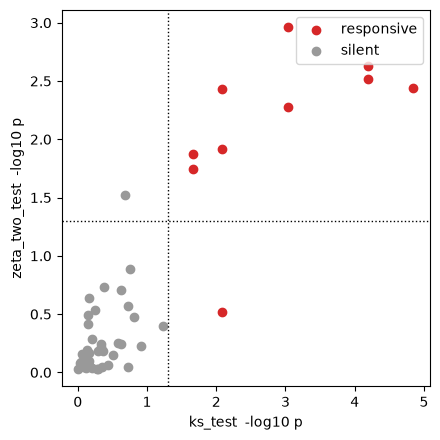

In [19]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
x = -np.log10(p_by_test["ks_test"])
y = -np.log10(p_by_test["zeta_two_test"])
ax.scatter(x[truth], y[truth], color="C3", label="responsive")
ax.scatter(x[~truth], y[~truth], color="0.6", label="silent")
for f in (ax.axvline, ax.axhline):
    f(-np.log10(0.05), color="k", ls=":", lw=1)
ax.set_xlabel("ks_test  -log10 p")
ax.set_ylabel("zeta_two_test  -log10 p")
ax.legend()
fig.tight_layout()
plt.show()

## Edge cases

In [20]:
# A group coordinate with 3 levels -> ValueError
f3 = silent.assign_coords(stim_type=("trial", np.resize(["a", "b", "c"], silent.sizes["trial"])))
try:
    stattest.ks_test(f3, "stim_type", window=WINDOW)
except ValueError as e:
    print("3 levels ->", e)

# Pass `groups` to pick two of them
print("groups=['a', 'b'] ->", stattest.ks_test(f3, "stim_type", groups=["a", "b"], window=WINDOW))

# Fewer than 2 trials in a group -> (nan, nan)
f_small = silent.isel(trial=[0, 1, 3, 5])  # 1 stim trial, 3 shutter trials
print("group with 1 trial ->", stattest.ks_test(f_small, "stim_type", window=WINDOW))

# NaN p-values are kept as NaN in fdr
print("fdr with NaN ->", stattest.fdr([0.01, np.nan, 0.04, 0.5]))

# zeta_two_test: fewer than 3 events in a group -> (nan, nan)
print("zeta_two_test, 2 events per group ->",
      stattest.zeta_two_test(dff.isel(cell=0), events.isel(event=slice(0, 4)), "stim_type"))

3 levels -> expected 2 groups, got [np.str_('a'), np.str_('b'), np.str_('c')]
groups=['a', 'b'] -> (0.11764705882352941, 0.9971476250179004)
group with 1 trial -> (nan, nan)
fdr with NaN -> [0.03  nan 0.06 0.5 ]
zeta_two_test, 2 events per group -> (nan, nan)


In [21]:
# circperm_test: events too close to the ends are dropped; an impossible min_shift raises
edge_dff, edge_ev = generate_traces(n_cells=1, duration=60.0, seed=5)
tr, ev = edge_dff.isel(cell=0), edge_ev.values
obs, p, null = stattest.circperm_test(tr, np.r_[0.1, ev, 59.9], window=(0.0, 2.0), baseline=(-1.0, 0.0), n_perm=200)
print("edge events dropped, p =", round(p, 3))
try:
    stattest.circperm_test(tr, ev, window=(0.0, 2.0), min_shift=40.0)
except ValueError as e:
    print("min_shift too large ->", e)

edge events dropped, p = 0.189
min_shift too large -> min_shift = 40 s leaves no allowed shifts for a 60 s trace


In [22]:
# Storey's pi0 = mean(p > 0.5) / 0.5, floored at 1/n. When no p-value is above 0.5,
# pi0 = 1/n and the q-values are BH's divided by n.
p_all_small = np.array([0.001, 0.01, 0.2, 0.3, 0.45])
print("bh    :", stattest.fdr(p_all_small, method="bh"))
print("storey:", stattest.fdr(p_all_small, method="storey"))

bh    : [0.005      0.025      0.33333333 0.375      0.45      ]
storey: [0.001      0.005      0.06666667 0.075      0.09      ]
